# Column Info

**Columns**
 -----
  **Well Identification and Location**
  
    WELL: Unique well identifier.
    DEPTH_MD: Measured depth (MD) in meters (vertical distance down the wellbore).
    X_LOC, Y_LOC: Easting and Northing coordinates (well's horizontal position, likely UTM).
    Z_LOC: Depth in a vertical coordinate system (elevation relative to sea level, different from DEPTH_MD).
  -----
  **Geological Information (Ground Truth)**

    GROUP: Broader geological grouping of formations.
    FORMATION: Specific geological formation at a given depth (finer subdivision than GROUP).
    FORCE_2020_LITHOFACIES_LITHOLOGY: Target variable: lithology (rock type) at each depth (categorical, with codes for different lithologies).
    FORCE_2020_LITHOFACIES_CONFIDENCE: Confidence in the assigned lithology label (important for evaluating model performance).
    Well Log Measurements (Features)
    CALI: Caliper log (borehole diameter).
    RSHA: Shallow resistivity log.
    RMED: Medium resistivity log.
    RDEP: Deep resistivity log.
    RHOB: Bulk density log.
    GR: Gamma-ray log.
    SGR: Spectral gamma ray log.
    NPHI: Neutron porosity log.
    PEF: Photoelectric factor log.
    DTC: Sonic/acoustic log (sound wave travel time).
    SP: Spontaneous potential log.
    BS: Bit size (diameter of the drill bit).
    ROP: Rate of penetration (drilling speed).
    DTS: Shear wave velocity log.
    DCAL: Difference between caliper and bit size.
    DRHO: Density correction.
    MUDWEIGHT: Density of the drilling mud.
    RMIC: Micro-resistivity log.
    ROPA: Processed/interpreted resistivity measurement.
    RXO: Resistivity of the flushed zone.
 -----
  **Dataset Use Cases**
  
    This dataset is suited for developing and testing machine learning models for lithology prediction.
    The various well log measurements provide valuable input features, while the FORCE_2020_LITHOFACIES_LITHOLOGY column serves as the target variable.
    The well location and geological information (GROUP, FORMATION) can provide additional context for analysis.
    The target code corresponds to lithologies that are mainly encountered in the North Sea reservoirs.
    The dataset is highly imbalanced, so keep this in mind.
 ------
    Code	Lithology
    30000	Sandstone
    65030	Sandstone/Shale
    65000	Shale
    80000	Marl
    74000	Dolomite
    70000	Limestone
    70032	Chalk
    88000	Halite
    86000	Anhydrite
    99000	Tuff
    90000	Coal
    93000	Basement

# Module & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

In [2]:
import kagglehub
path = kagglehub.dataset_download("kawatgiomkar/lithology")

100%|██████████| 86.8M/86.8M [00:01<00:00, 82.3MB/s]

Extracting files...


In [3]:
os.listdir(path)

['CSV_train.csv']

In [4]:
df = pd.read_csv(path + '/CSV_train.csv',sep=';')
df.shape

(1170511, 29)

In [5]:
df=df[df['WELL']=='25/4-5']
df.shape

(23005, 29)

In [6]:
df.head(1)

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
309361,25/4-5,853.302805,454469.53125,6603730.0,-828.002808,HORDALAND GP.,Utsira Fm.,19.158823,NaN,1.163803,...,NaN,NaN,1.658824,NaN,NaN,NaN,NaN,NaN,65000,1.0




---



# Data Preprocessing

## Null Values

In [7]:
print(df.isnull().sum())

WELL                                     0
DEPTH_MD                                 0
X_LOC                                    0
Y_LOC                                    0
Z_LOC                                    0
GROUP                                    0
FORMATION                                0
CALI                                     0
RSHA                                 16778
RMED                                     9
RDEP                                     0
RHOB                                     0
GR                                       0
SGR                                  23005
NPHI                                     0
PEF                                  17226
DTC                                     56
SP                                   23005
BS                                       0
ROP                                  23005
DTS                                  23005
DCAL                                     0
DRHO                                    26
MUDWEIGHT  

**SGR, SP, ROP, MUDWEIGHT, DTS, RXO, ROPA Are not used entirly in this well**

**RSHA, PEF, RMIC -> 80% null**



### Columns To Drop

In [8]:
col= ['SGR','SP','ROP','MUDWEIGHT','DTS','RXO', 'RMIC','ROPA','PEF', 'RSHA', 'RXO']
df.drop(col, axis=1, inplace=True)

In [9]:
df_clean =df.interpolate(method='linear', limit_direction='both')

In [10]:
print(df_clean.isnull().sum())

WELL                                 0
DEPTH_MD                             0
X_LOC                                0
Y_LOC                                0
Z_LOC                                0
GROUP                                0
FORMATION                            0
CALI                                 0
RMED                                 0
RDEP                                 0
RHOB                                 0
GR                                   0
NPHI                                 0
DTC                                  0
BS                                   0
DCAL                                 0
DRHO                                 0
FORCE_2020_LITHOFACIES_LITHOLOGY     0
FORCE_2020_LITHOFACIES_CONFIDENCE    0
dtype: int64


we can still get 90%+ accuracy with just the "Triple Combo":

- Gamma Ray (GR): Distinguishes Shale vs. Non-Shale.

- Density (RHOB): Distinguishes Tight Rock vs. Porous Rock.

- Neutron (NPHI): Used with Density to spot Gas effects and confirm Lithology

## Duplicated Values

In [11]:
df_clean.duplicated().sum()

np.int64(0)

## Data Mis-Type

In [12]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23005 entries, 309361 to 332365
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   WELL                               23005 non-null  object 
 1   DEPTH_MD                           23005 non-null  float64
 2   X_LOC                              23005 non-null  float64
 3   Y_LOC                              23005 non-null  float64
 4   Z_LOC                              23005 non-null  float64
 5   GROUP                              23005 non-null  object 
 6   FORMATION                          23005 non-null  object 
 7   CALI                               23005 non-null  float64
 8   RMED                               23005 non-null  float64
 9   RDEP                               23005 non-null  float64
 10  RHOB                               23005 non-null  float64
 11  GR                                 23005 non-null  fl



---




# Log Plot

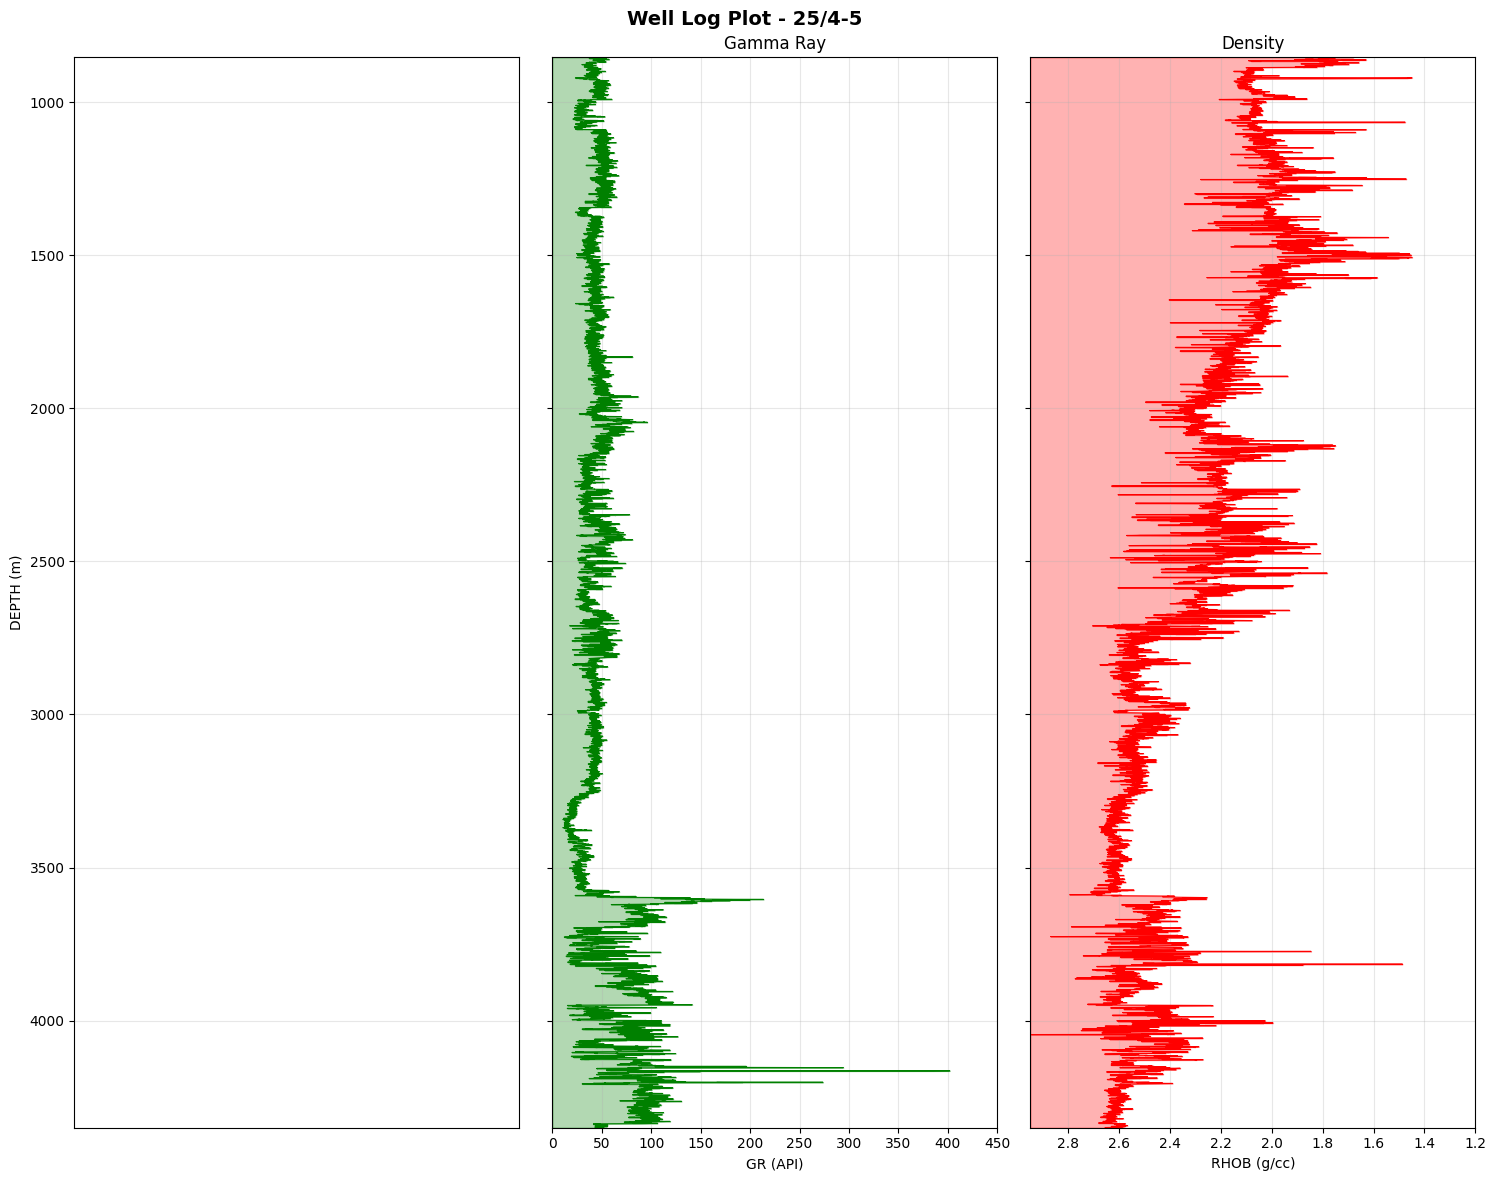

In [13]:
df_clean = df_clean.sort_values('DEPTH_MD')

# (tracks)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 12), sharey=True)

# (well name)
well_name = df_clean['WELL'].iloc[0]
fig.suptitle(f'Well Log Plot - {well_name}', fontsize=14, fontweight='bold')

# ----------------------------------------

# Track 1: Depth Track
ax1.set_ylabel('DEPTH (m)')
ax1.invert_yaxis()  # Invert y-axis so depth increases downward
ax1.grid(True, alpha=0.3)

# Add depth ticks on the left
ax1.set_ylim(df_clean['DEPTH_MD'].max(), df_clean['DEPTH_MD'].min())  # Inverted
ax1.get_xaxis().set_visible(False)  # Hide x-axis for depth track

# ----------------------------------------

# Track 2: Gamma Ray (GR)
ax2.plot(df_clean['GR'], df_clean['DEPTH_MD'], color='green', linewidth=0.8)
ax2.set_xlabel('GR (API)')
ax2.set_title('Gamma Ray')
ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()
ax2.set_xlim(0, 450)
ax2.fill_betweenx(df_clean['DEPTH_MD'], 0, df_clean['GR'],
                  where=(df_clean['GR'] > 0),
                  color='green', alpha=0.3)

# ----------------------------------------


# Track 3: Density (RHOB)
ax3.plot(df_clean['RHOB'], df_clean['DEPTH_MD'], color='red', linewidth=0.8)
ax3.set_xlabel('RHOB (g/cc)')
ax3.set_title('Density')
ax3.grid(True, alpha=0.3)
ax3.invert_yaxis()
ax3.set_xlim(1.2, 2.95)
# Invert x-axis for density (common practice - lower density to the right)
ax3.invert_xaxis()

ax3.fill_betweenx(df_clean['DEPTH_MD'], df_clean['RHOB'], 2.95,  # Fill from curve to right edge
                  color='red', alpha=0.3)

# Adjust layout
plt.subplots_adjust(wspace=0.05)  # Reduce space between tracks
plt.tight_layout()
plt.show()



# Cross Plot

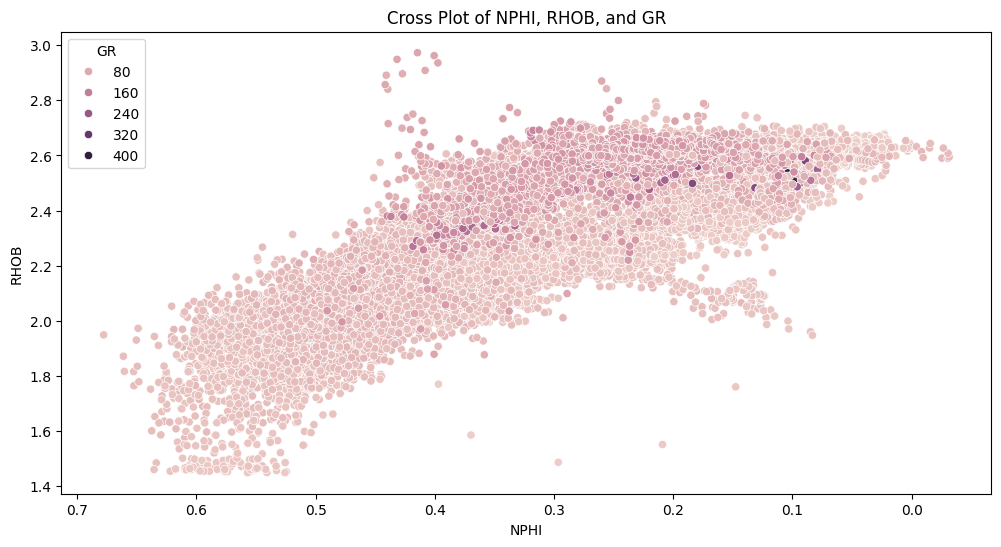

In [14]:
plt.figure(figsize=(12, 6))
sns.scatterplot(df_clean,x='NPHI',y='RHOB',hue='GR')
# plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.title('Cross Plot of NPHI, RHOB, and GR')
plt.show()



---
# Modeling


## Random Forest Classifier

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [16]:
# Define features and target
X = df_clean[['DEPTH_MD', 'GR', 'RHOB', 'NPHI']]

y = df_clean['FORCE_2020_LITHOFACIES_LITHOLOGY']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9171919148011302


In [24]:
print("Classification Report", classification_report(y_test, y_pred))

Classification Report               precision    recall  f1-score   support

       30000       0.92      0.95      0.94       909
       65000       0.92      0.94      0.93      1777
       65030       0.81      0.76      0.78       596
       70000       0.94      0.88      0.91       446
       80000       0.96      0.98      0.97       824
       90000       0.83      0.71      0.77         7
       99000       0.84      0.90      0.87        42

    accuracy                           0.92      4601
   macro avg       0.89      0.87      0.88      4601
weighted avg       0.92      0.92      0.92      4601



In [29]:
df_slice = df_clean[(df_clean['DEPTH_MD'] >= 2000) & (df_clean['DEPTH_MD'] <= 2500)]

In [30]:
X_slice = df_slice[['DEPTH_MD', 'GR', 'RHOB', 'NPHI']]
y_slice_pred = rf.predict(X_slice)
df_slice['PREDICTED_LITHOLOGY'] = y_slice_pred

In [32]:
lithology_dict = {
    30000: 'Sandstone',
    65030: 'Sandstone/Shale',
    65000: 'Shale',
    80000: 'Marl',
    74000: 'Dolomite',
    70000: 'Limestone',
    70032: 'Chalk',
    88000: 'Halite',
    86000: 'Anhydrite',
    99000: 'Tuff',
    90000: 'Coal',
    93000: 'Basement'
}

df_slice['LITHOLOGY_NAME'] = df_slice['FORCE_2020_LITHOFACIES_LITHOLOGY'].map(lithology_dict)
df_slice['PREDICTED_LITHOLOGY_NAME'] = df_slice['PREDICTED_LITHOLOGY'].map(lithology_dict)

print(df_slice[['DEPTH_MD', 'LITHOLOGY_NAME', 'PREDICTED_LITHOLOGY_NAME']].head())

           DEPTH_MD LITHOLOGY_NAME PREDICTED_LITHOLOGY_NAME
316906  2000.142805           Tuff                     Tuff
316907  2000.294805           Tuff                     Tuff
316908  2000.446805           Tuff                     Tuff
316909  2000.598805           Tuff                     Tuff
316910  2000.750805           Tuff                     Tuff


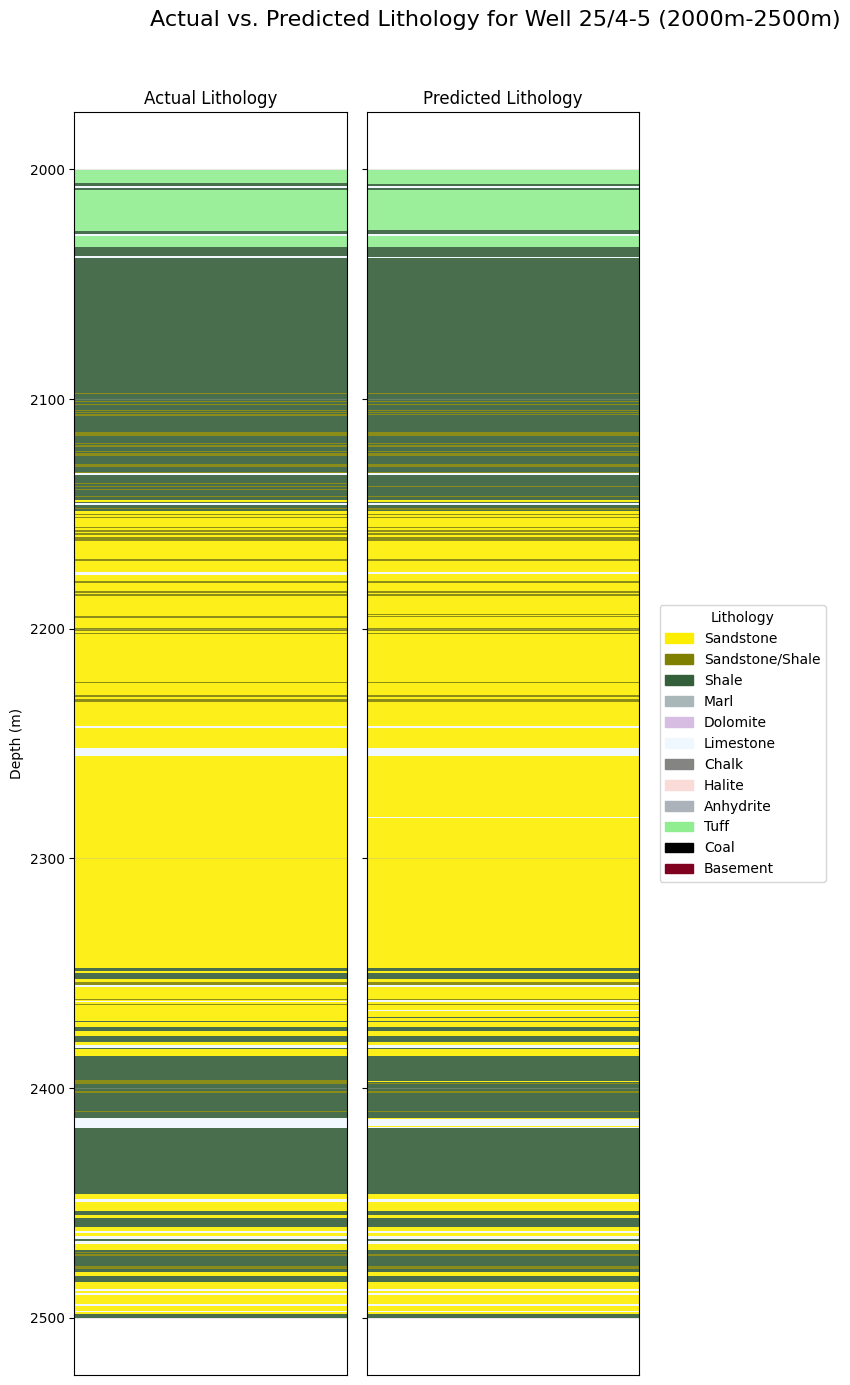

In [35]:
lithology_colors = {
    'Sandstone': '#FDEE00',
    'Sandstone/Shale': '#808000',
    'Shale': '#355E3B',
    'Marl': '#AAB7B8',
    'Dolomite': '#D7BDE2',
    'Limestone': '#F0F8FF',
    'Chalk': '#848482',
    'Halite': '#FADBD8',
    'Anhydrite': '#ABB2B9',
    'Tuff': '#90EE90',
    'Coal': '#000000',
    'Basement': '#800020'
}

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(10, 15), sharey=True)

# Plot Actual Lithology
axes[0].plot(df_slice['DEPTH_MD'], df_slice['DEPTH_MD'], color='white', linewidth=0)


# Dummy plot to get depth range
current_lithology = None
start_depth = None


for idx, row in df_slice.iterrows():
    if current_lithology is None:
        current_lithology = row['LITHOLOGY_NAME']
        start_depth = row['DEPTH_MD']



    elif row['LITHOLOGY_NAME'] != current_lithology:
        end_depth = row['DEPTH_MD']
        axes[0].axhspan(start_depth, end_depth, facecolor=lithology_colors.get(current_lithology, '#CCCCCC'), alpha=0.9)
        current_lithology = row['LITHOLOGY_NAME']
        start_depth = row['DEPTH_MD']




# Handle the last lithology section
if current_lithology is not None:
    axes[0].axhspan(start_depth, df_slice['DEPTH_MD'].iloc[-1], facecolor=lithology_colors.get(current_lithology, '#CCCCCC'), alpha=0.9)




axes[0].set_title('Actual Lithology')
axes[0].set_ylabel('Depth (m)')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1) # Dummy x-limit
axes[0].set_xticks([]) # Hide x-axis ticks




# Plot Predicted Lithology
axes[1].plot(df_slice['DEPTH_MD'], df_slice['DEPTH_MD'], color='white', linewidth=0) # Dummy plot to get depth range


current_predicted_lithology = None
start_depth_pred = None


for idx, row in df_slice.iterrows():
    if current_predicted_lithology is None:
        current_predicted_lithology = row['PREDICTED_LITHOLOGY_NAME']
        start_depth_pred = row['DEPTH_MD']


    elif row['PREDICTED_LITHOLOGY_NAME'] != current_predicted_lithology:
        end_depth_pred = row['DEPTH_MD']
        axes[1].axhspan(start_depth_pred, end_depth_pred, facecolor=lithology_colors.get(current_predicted_lithology, '#CCCCCC'), alpha=0.9)
        current_predicted_lithology = row['PREDICTED_LITHOLOGY_NAME']
        start_depth_pred = row['DEPTH_MD']



# Handle the last lithology section
if current_predicted_lithology is not None:
    axes[1].axhspan(start_depth_pred, df_slice['DEPTH_MD'].iloc[-1], facecolor=lithology_colors.get(current_predicted_lithology, '#CCCCCC'), alpha=0.9)



axes[1].set_title('Predicted Lithology')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1) # Dummy x-limit
axes[1].set_xticks([]) # Hide x-axis ticks


# Create a legend
legend_handles = [plt.Rectangle((0,0),1,1, color=lithology_colors[name]) for name in lithology_colors.keys()]
axes[1].legend(legend_handles, lithology_colors.keys(), title="Lithology", loc='center left', bbox_to_anchor=(1.05, 0.5))


plt.suptitle(f'Actual vs. Predicted Lithology for Well {df_slice["WELL"].iloc[0]} (2000m-2500m)', y=0.92, fontsize=16)
plt.tight_layout(rect=[0, 0, 0.85, 0.9])
plt.show()

## Summary:

### Q&A
The visual comparison between the actual and predicted lithology for the depth range of 2000m to 2500m shows a good overall fit, especially for larger lithology blocks.

The Random Forest Classifier successfully identified prominent lithological boundaries and maintained consistency across significant depth intervals.

Areas of good fit include the accurate prediction of dominant lithology types (e.g., Tuff, Shale) in continuous sections and reasonably well-captured transitions between lithology types.

Discrepancies include the model missing or slightly mispredicting smaller, finer-scale lithological changes and imperfect reproduction of very thin beds or interbedded sections, where the model tends to generalize these features.

### Data Analysis Key Findings
*   The Random Forest Classifier accurately predicted dominant lithology types (e.g., Tuff, Shale) in large, continuous sections within the 2000m-2500m depth range.


*   The model effectively captured many transitions between different lithology types, indicating its ability to interpret changes in well log features at various depths.


*   Discrepancies primarily involved smaller, finer-scale lithological changes and very thin beds, which the model sometimes missed, predicted slightly off-depth, or generalized.


*   The overall performance of the Random Forest Classifier in predicting the general lithological sequence and major rock types in this section is strong, consistent with its reported overall accuracy of 91.7%.

### Insights or Next Steps
*   Further refinement of the model could focus on improving the prediction of thin beds and fine-scale lithological variations, possibly by exploring different model architectures or feature engineering techniques that emphasize high-resolution changes.


*   Quantifying the types and magnitudes of discrepancies (e.g., measuring the depth error for boundary predictions or the percentage of thin beds missed) could provide more targeted areas for model improvement.




---

